# Exercises

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Exercises

## 3.1 Concrete items

A construction company receives concrete items for a construction. The length of the items are assumed reasonably normally distributed. The following requirements for the length of the elements are made

$$\mu = 3000 \text{ mm}.$$

The company samples 9 items from a delivery which are then measured for control. The following measurements (in mm) are found:

$$3003 \quad 3005 \quad 2997 \quad 3006 \quad 2999 \quad 2998 \quad 3007 \quad 3005 \quad 3001$$

### a) 
Compute the following three statistics: the sample mean, the sample standard deviation and the standard error of the mean, and what are the interpretations of these statistics?

**Solution:**

The sample mean $\bar{y} = 3002.3333$ mm is our estimate of the true population mean $\mu$ — i.e. the best guess of the average length of all items in the delivery.

The sample standard deviation $s = 3.7081$ mm describes the spread of the individual measurements around the sample mean — i.e. how much a single item's length typically deviates from the average.

The standard error of the mean $s/\sqrt{n} = 1.2360$ mm describes the uncertainty in our estimate of $\mu$ — i.e. how much the sample mean $\bar{y}$ would typically vary if we repeated the sampling.


In [5]:
samples = np.array([3003, 3005, 2997, 3006, 2999, 2998, 3007, 3005, 3001])

sample_mean = np.mean(samples)
sample_std = np.std(samples, ddof=1)
standard_error = sample_std / np.sqrt(len(samples))

print(f"Sample mean       y_bar = {sample_mean:.4f} mm")
print(f"Sample std dev        s = {sample_std:.4f} mm")
print(f"Standard error  s/√n   = {standard_error:.4f} mm")

Sample mean       y_bar = 3002.3333 mm
Sample std dev        s = 3.7081 mm
Standard error  s/√n   = 1.2360 mm


### b)
In a construction process, 5 concrete items are joined together to a single construction with a length which is then the complete length of the 5 concrete items. It is very important that the length of this new construction is within 15 m plus/minus 1 cm. How often will it happen that such a construction will be more than 1 cm away from the 15 m target (assume that the population mean concrete item length is $\mu = 3000$ mm and that the population standard deviation is $\sigma = 3$)?

**Solution:**

In [6]:
mu_T = 5 * 3000
sigma_T = np.sqrt(5 * 3**2)

T = stats.norm(loc=mu_T, scale=sigma_T)

p_outside = T.cdf(14990) + (1 - T.cdf(15010))
print(f"mu_T    = {mu_T} mm")
print(f"sigma_T = {sigma_T:.4f} mm")
print(f"P(|T - 15000| > 10) = {p_outside:.4f}")

mu_T    = 15000 mm
sigma_T = 6.7082 mm
P(|T - 15000| > 10) = 0.1360


### c)
Find the 95% confidence interval for the mean $\mu$.

**Solution:**

In [9]:
alpha = 0.05 # from 1-alpha = 0.95 confidence level
n = len(samples)
confidence_level = 1 - alpha

interval = stats.t.interval(confidence_level, df=n-1, loc=sample_mean, scale=standard_error)

print(f"{confidence_level*100:.0f}% confidence interval for mu: {interval[0]:.4f} mm to {interval[1]:.4f} mm")

95% confidence interval for mu: 2999.4830 mm to 3005.1836 mm


### d)
Find the 99% confidence interval for $\mu$. Compare with the 95% one from above and explain why it is smaller/larger!

**Solution:**

we see a slightly larger confidence interval for the 99% confidence level compared to the 95% confidence level. This is because a higher confidence level requires a wider interval to ensure that it captures the true population mean $\mu$ with greater certainty. The critical value from the t-distribution increases as the confidence level increases, leading to a wider interval.

In [10]:
alpha = 0.01 # from 1-alpha = 0.99 confidence level
confidence_level = 1 - alpha

interval = stats.t.interval(confidence_level, df=n-1, loc=sample_mean, scale=standard_error)

print(f"{confidence_level*100:.0f}% confidence interval for mu: {interval[0]:.4f} mm to {interval[1]:.4f} mm")

99% confidence interval for mu: 2998.1860 mm to 3006.4807 mm


### e)
Find the 95% confidence intervals for the variance $\sigma^2$ and the standard deviation $\sigma$.

**Solution:**

In [16]:
alpha = 0.05
confidence_level = 1 - alpha

chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)
chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)

var_lower = ((n-1) * sample_std**2) / chi2_upper
var_upper = ((n-1) * sample_std**2) / chi2_lower

std_lower = np.sqrt(var_lower)
std_upper = np.sqrt(var_upper)

print(f"{confidence_level*100:.0f}% confidence interval for variance: {var_lower:.4f} mm^2 to {var_upper:.4f} mm^2")

print(f"{confidence_level*100:.0f}% confidence interval for std dev: {std_lower:.4f} mm to {std_upper:.4f} mm")

95% confidence interval for variance: 6.2733 mm^2 to 50.4649 mm^2
95% confidence interval for std dev: 2.5047 mm to 7.1039 mm


### f)
Find the 99% confidence intervals for the variance $\sigma^2$ and the standard deviation $\sigma$.

**Solution:**
The 99% confidence intervals for both $\sigma^2$ and $\sigma$ are wider than the 95% ones, for the same reason as in d). A higher confidence level requires a wider interval.

In [17]:
alpha = 0.01
confidence_level = 1 - alpha

chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)
chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)

var_lower = ((n-1) * sample_std**2) / chi2_upper
var_upper = ((n-1) * sample_std**2) / chi2_lower

std_lower = np.sqrt(var_lower)
std_upper = np.sqrt(var_upper)

print(f"{confidence_level*100:.0f}% confidence interval for variance: {var_lower:.4f} mm^2 to {var_upper:.4f} mm^2")

print(f"{confidence_level*100:.0f}% confidence interval for std dev: {std_lower:.4f} mm to {std_upper:.4f} mm")

99% confidence interval for variance: 5.0103 mm^2 to 81.8201 mm^2
99% confidence interval for std dev: 2.2384 mm to 9.0454 mm


## 3.2 Aluminum profile

The length of an aluminum profile is checked by taking a sample of 16 items whose length is measured. The measurement results from this sample are listed below, all measurements are in mm:

$$180.02 \quad 180.00 \quad 180.01 \quad 179.97 \quad 179.92 \quad 180.05 \quad 179.94 \quad 180.10$$
$$180.24 \quad 180.12 \quad 180.13 \quad 180.22 \quad 179.96 \quad 180.10 \quad 179.96 \quad 180.06$$

From data is obtained: $\bar{x} = 180.05$ and $s = 0.0959$.

It can be assumed that the sample comes from a population which is normally distributed.

### a)
A 90%-confidence interval for $\mu$ becomes?

**Solution:**

In [19]:
x_bar = 180.05
s = 0.0959
n = 16
standard_error = s / np.sqrt(n)

alpha = 0.10
confidence_level = 1 - alpha
interval = stats.t.interval(confidence_level, df=n-1, loc=x_bar, scale=standard_error)
print(f"{confidence_level*100:.0f}% confidence interval for mu: {interval[0]:.4f} mm to {interval[1]:.4f} mm")

90% confidence interval for mu: 180.0080 mm to 180.0920 mm


### b)
A 99%-confidence interval for $\sigma$ becomes?

**Solution:**

In [22]:
alpha = 0.01 # from 1-alpha = 0.99 confidence level
confidence_level = 1 - alpha

chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)
chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)

var_lower = ((n-1) * s**2) / chi2_upper
var_upper = ((n-1) * s**2) / chi2_lower

std_lower = np.sqrt(var_lower)
std_upper = np.sqrt(var_upper)

print(f"{confidence_level*100:.0f}% confidence interval for standard deviation: {std_lower:.4f} mm to {std_upper:.4f} mm")


99% confidence interval for standard deviation: 0.0649 mm to 0.1732 mm


## 3.3 Concrete items (hypothesis testing)

This is a continuation of Exercise 3.1, so the same setting and data is used (read the initial text of it).

### a)
To investigate whether the requirement to the mean is fulfilled (with $\alpha = 5\%$), the following hypothesis should be tested

$$H_0 : \mu = 3000$$
$$H_1 : \mu \neq 3000.$$

Or similarly asked: what is the evidence against the null hypothesis?

**Solution:**

In [25]:
# Data from 3.1
samples = np.array([3003, 3005, 2997, 3006, 2999, 2998, 3007, 3005, 3001])
n = len(samples)
sample_mean = np.mean(samples)
sample_std = np.std(samples, ddof=1)
standard_error = sample_std / np.sqrt(n)

mu_0 = 3000
alpha = 0.05
t_obs = (sample_mean - mu_0) / standard_error
p_value = 2 * (1 - stats.t.cdf(abs(t_obs), df=n-1))

print(f"t_obs:   {t_obs:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0: {p_value < alpha}")

t_obs:   1.8878
p-value: 0.0958
Reject H0: False


### b)
What would the level $\alpha = 0.01$ critical values be for this test, and what are the interpretation of these?

**Solution:**

In [27]:
alpha_b = 0.01

t_crit = stats.t.ppf(1 - alpha_b/2, df=n-1)

print(f"\nCritical values: +/- {t_crit:.4f}")
print(f"Reject H0: {abs(t_obs) > t_crit}")


Critical values: +/- 3.3554
Reject H0: False


### c)
What would the level $\alpha = 0.05$ critical values be for this test (compare also with the values found in the previous question)?

**Solution:**

In [28]:
alpha_b = 0.05

t_crit = stats.t.ppf(1 - alpha_b/2, df=n-1)

print(f"\nCritical values: +/- {t_crit:.4f}")
print(f"Reject H0: {abs(t_obs) > t_crit}")


Critical values: +/- 2.3060
Reject H0: False


### d)
Investigate, by some plots, whether the data here appears to be coming from a normal distribution (as assumed until now)?

**Solution:**
With only $n = 9$ observations it is difficult to conclude definitively, but the Q-Q plot shows points roughly following the straight line and the histogram shows no strong skewness. The normality assumption appears reasonable.

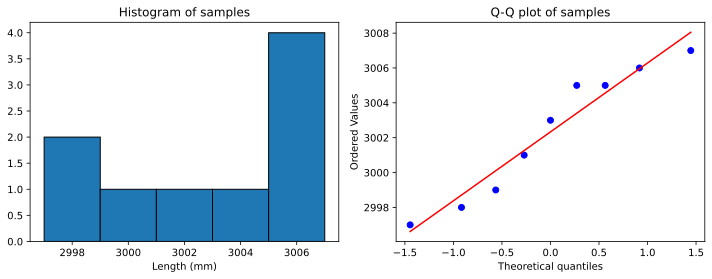

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axes[0].hist(samples, bins=5, edgecolor='black')
axes[0].set_title('Histogram of samples')
axes[0].set_xlabel('Length (mm)')

# Q-Q plot
stats.probplot(samples, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot of samples')

plt.tight_layout()
plt.show()

### e)
Assuming that you, maybe among different plots, also did the normal Q-Q plot above, the question is now: What exactly is plotted in that plot? Or more specifically: what are the x- and y-coordinates of e.g. the two points to the lower left in this plot?

**Solution:**
The Q-Q plot compares the sorted sample values against the theoretical quantiles of the normal distribution. Specifically:

- **y-axis**: the sorted sample values $x_{(1)} \leq x_{(2)} \leq \cdots \leq x_{(n)}$
- **x-axis**: the theoretical normal quantiles $\Phi^{-1}(p_i)$ where $p_i = \frac{i - 0.5}{n}$

The two points in the lower left correspond to the two smallest observations $x_{(1)} = 2997$ and $x_{(2)} = 2998$, plotted against $\Phi^{-1}(p_1)$ and $\Phi^{-1}(p_2)$ respectively. If the data comes from a normal distribution, the points should fall approximately on a straight line.

In [30]:
n = len(samples)
sorted_samples = np.sort(samples)

for i in range(1, 4):  # first few points
    p_i = (i - 0.5) / n
    theoretical_q = stats.norm.ppf(p_i, loc=sample_mean, scale=sample_std)
    print(f"Point {i}: x={theoretical_q:.4f}, y={sorted_samples[i-1]}")

Point 1: x=2996.4255, y=2997
Point 2: x=2998.7460, y=2998
Point 3: x=3000.1476, y=2999


## 3.4 Aluminum profile (hypothesis testing)

We use the same setting and data as in Exercise 3.2, so read the initial text of it.

### a)
Find the evidence against the following hypothesis:

$$H_0 : \mu = 180.$$

**Solution:**

In [31]:
x_bar = 180.05
s = 0.0959
n = 16
standard_error = s / np.sqrt(n)



### b)
If the following hypothesis test is carried out

$$H_0 : \mu = 180,$$
$$H_1 : \mu \neq 180.$$

What are the level $\alpha = 1\%$ critical values for this test?

**Solution:**

### c)
What is the 99%-confidence interval for $\mu$?

**Solution:**

### d)
Carry out the following hypothesis test

$$H_0 : \mu = 180,$$
$$H_1 : \mu \neq 180,$$

using $\alpha = 5\%$.

**Solution:**

## E9.7 Correlation

### a)
With $r$ as in (9-51), what is the correlation between $r_i$ and $r_j$?

**Solution:**

## E9.9 Orthogonal projections

### a)
With $H_1$ and $H_2$ as in (9-70), show that $\text{Cov}[H_1 Z, H_2 Z] = 0$. Hint: Use Theorem 9.10 and Exercise 5.

**Solution:**

# Exercises

## 3.1 Concrete items

### a) 
Compute the following three statistics: the sample mean, the sample standard deviation and the standard error of the mean, and what are the interpretations of these statistics?

**Solution:**